# Gradient Boosting Regressor 2 - Model Development Workflow

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn
- A full workflow on real insurance costs: skewed target → `log1p` → dollars back via `expm1`
- The **staged API**: using `staged_predict` to find the best number of trees honestly
- A learning-rate × max_depth grid, read as a heatmap of validation scores
- Why `smoker` will dominate feature importances before you even look

### Inline plotting for Jupyter; plain-Python runs fall through harmlessly.


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:          # walk up to the course root
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

INS_CSV = DATA_DIR / "insurance.csv"
if not INS_CSV.exists():                             # download-once helper
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/"
        "master/insurance.csv", INS_CSV)

df = pd.read_csv(INS_CSV)                            # REAL US insurer sample, n=1338
print(df.shape)
df.head(3)


### 1. EDA - the target is money, so it is skewed


C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_75532\2844829236.py:17: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


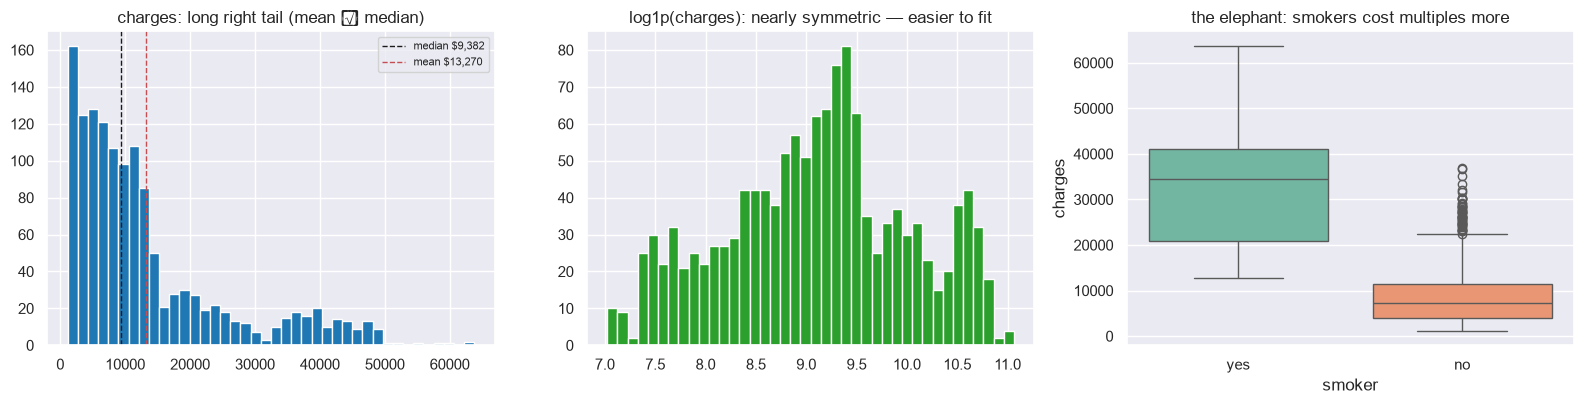

skew of charges     : 1.52
skew of log1p       : -0.09


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].hist(df["charges"], bins=40, color="tab:blue", edgecolor="white")
axes[0].axvline(df["charges"].median(), color="k", ls="--", lw=1,
                label=f"median ${df['charges'].median():,.0f}")
axes[0].axvline(df["charges"].mean(), color="r", ls="--", lw=1,
                label=f"mean ${df['charges'].mean():,.0f}")
axes[0].set_title("charges: long right tail (mean ≫ median)")
axes[0].legend(fontsize=8)

axes[1].hist(np.log1p(df["charges"]), bins=40, color="tab:green", edgecolor="white")
axes[1].set_title("log1p(charges): nearly symmetric - easier to fit")

sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", palette="Set2",
            legend=False, ax=axes[2])
axes[2].set_title("the elephant: smokers cost multiples more")
plt.tight_layout(); plt.show()

print(f"skew of charges     : {df['charges'].skew():.2f}")
print(f"skew of log1p       : {np.log1p(df['charges']).skew():.2f}")
# 💡 WHY log-transform? Squared-error models chase big values hardest; a few
#    $60k claims would dominate the loss. Modelling log1p makes errors RELATIVE
#    (% mistakes), then expm1 maps predictions back to dollars for reporting.

### 2. Processing & a three-way split

- One-hot encode the three categorical columns (`sex`, `smoker`, `region`) with
  `drop_first=True` - categories are fixed, so no leakage from doing this pre-split.
- Split into TRAIN (fit), VALIDATION (choose rounds/hyperparams), TEST (touched once).
- Model the LOGARITHM of charges; every metric below is computed back in DOLLARS.

In [3]:
df_enc = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)
X = df_enc.drop(columns=["charges"])
y_log = np.log1p(df["charges"])                      # learn in log space

X_train, X_hold, y_train, y_hold = train_test_split(X, y_log, test_size=0.40,
                                                    random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_hold, y_hold, test_size=0.50,
                                                    random_state=42)
print(f"train {X_train.shape} | valid {X_valid.shape} | test {X_test.shape}")

def dollar_metrics(y_log_true, pred_log):
    """Undo log1p on truth+prediction, then compute $ metrics."""
    dollars_true = np.expm1(y_log_true)
    dollars_pred = np.expm1(pred_log)
    return {
        "MAE_$": mean_absolute_error(dollars_true, dollars_pred),
        "RMSE_$": mean_squared_error(dollars_true, dollars_pred) ** 0.5,
        "R²": r2_score(dollars_true, dollars_pred),
    }

train (802, 8) | valid (268, 8) | test (268, 8)


### 3. Baselines, then the boosting model


In [4]:
rows = {}
lin = LinearRegression().fit(X_train, y_train)                    # linear yardstick
rows["Linear regression"] = dollar_metrics(y_valid, lin.predict(X_valid))
gbm_base = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
rows["GBM defaults"] = dollar_metrics(y_valid, gbm_base.predict(X_valid))
pd.DataFrame(rows).T.round(0)

,MAE_$,RMSE_$,R²
Linear regression,3472.0,6962.0,1.0
GBM defaults,2116.0,4810.0,1.0


### 4. THE staged API - pick the number of trees with data, not vibes

`staged_predict` yields the model's prediction after EVERY round (1 tree, 2 trees, …).
Score each prefix on the VALIDATION set and take the argmin - that is honest early
stopping done after the fact. ⚠️ Do NOT run this against the test set; validation only.

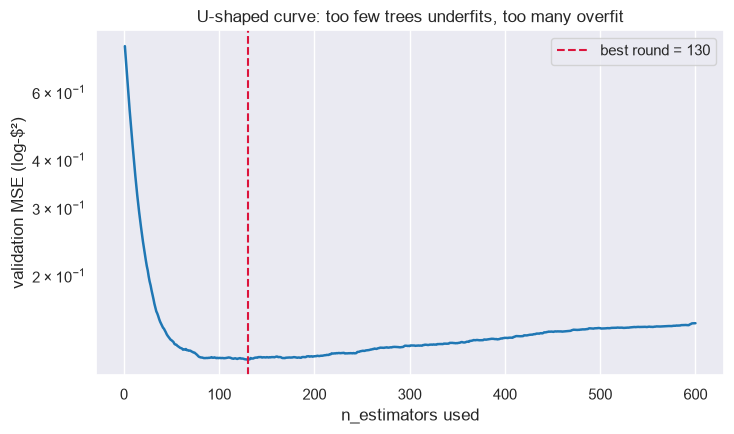

validation MSE fell until round 130, then rose — classic overfit knee


,MAE_$,RMSE_$,R²
Linear regression,3472.0,6962.0,1.0
GBM defaults,2116.0,4810.0,1.0
GBM tuned (130 trees),2150.0,4590.0,1.0


In [5]:
big_gbm = GradientBoostingRegressor(
    n_estimators=600,         # plenty of rope
    learning_rate=0.05,       # small steps -> smooth curve worth scanning
    max_depth=3,
    subsample=0.8,            # mild stochasticity
    random_state=42,
).fit(X_train, y_train)

staged_mse = [mean_squared_error(y_valid, p) for p in big_gbm.staged_predict(X_valid)]
best_round = int(np.argmin(staged_mse)) + 1        # +1: stages count from 1 tree

plt.figure(figsize=(7.5, 4.5))
plt.plot(range(1, len(staged_mse) + 1), staged_mse, color="tab:blue", lw=1.8)
plt.axvline(best_round, color="crimson", ls="--",
            label=f"best round = {best_round}")
plt.yscale("log"); plt.xlabel("n_estimators used"); plt.ylabel("validation MSE (log-$²)")
plt.title("U-shaped curve: too few trees underfits, too many overfit")
plt.legend(); plt.tight_layout(); plt.show()

print(f"validation MSE fell until round {best_round}, then rose - classic overfit knee")

# Refit the winning size on train+VALID (more data now that the choice is made).
final_gbm = GradientBoostingRegressor(
    n_estimators=best_round, learning_rate=0.05, max_depth=3, subsample=0.8,
    random_state=42,
).fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]))
rows[f"GBM tuned ({best_round} trees)"] = dollar_metrics(
    y_test, final_gbm.predict(X_test))             # test touched exactly ONCE
pd.DataFrame(rows).T.round(0)

### 5. Grid: learning_rate × max_depth (each cell picks its own best stage)


depth=2 lr=0.03 best-stage R²=0.8494 @ round 246


depth=2 lr=0.1  best-stage R²=0.8515 @ round 57


depth=2 lr=0.3  best-stage R²=0.8516 @ round 37


depth=3 lr=0.03 best-stage R²=0.8604 @ round 168


depth=3 lr=0.1  best-stage R²=0.8599 @ round 46


depth=3 lr=0.3  best-stage R²=0.8546 @ round 10


depth=4 lr=0.03 best-stage R²=0.8612 @ round 147


depth=4 lr=0.1  best-stage R²=0.8596 @ round 53


depth=4 lr=0.3  best-stage R²=0.8585 @ round 13


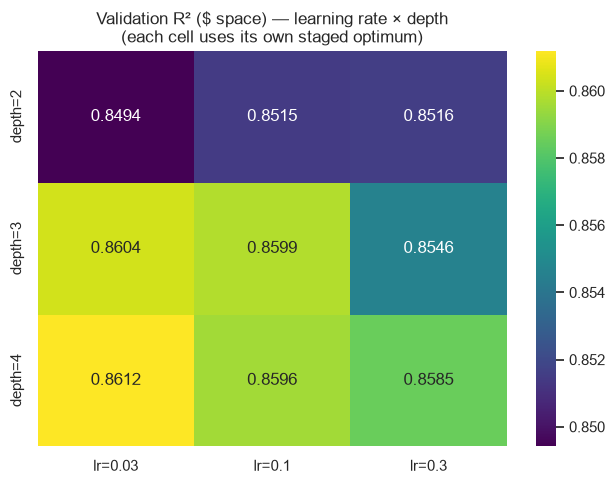

In [6]:
lrs = [0.03, 0.1, 0.3]
depths = [2, 3, 4]
grid_r2 = np.zeros((len(depths), len(lrs)))        # rows=depth, cols=lr

for i, d in enumerate(depths):                     # loop order chosen for tidy heatmap axes
    for j, lr in enumerate(lrs):
        m = GradientBoostingRegressor(n_estimators=600, learning_rate=lr,
                                      max_depth=d, subsample=0.8,
                                      random_state=42).fit(X_train, y_train)
        # per-cell early stop: best validation dollar-R² across stages
        r2s = [r2_score(np.expm1(y_valid), np.expm1(p))
               for p in m.staged_predict(X_valid)]
        grid_r2[i, j] = max(r2s)
        print(f"depth={d} lr={lr:<4} best-stage R²={grid_r2[i, j]:.4f} "
              f"@ round {int(np.argmax(r2s)) + 1}")

grid_df = pd.DataFrame(grid_r2, index=[f"depth={d}" for d in depths],
                       columns=[f"lr={v}" for v in lrs])
plt.figure(figsize=(6.5, 5))
sns.heatmap(grid_df, annot=True, fmt=".4f", cmap="viridis")
plt.title("Validation R² ($ space) - learning rate × depth\n(each cell uses its own staged optimum)")
plt.tight_layout(); plt.show()

### 6. What drives premiums? Importances in plain language


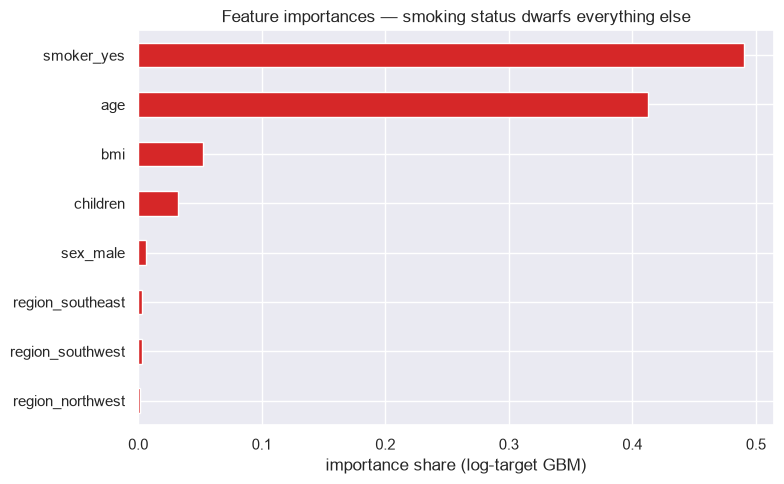

top-4: {'smoker_yes': 0.49, 'age': 0.412, 'bmi': 0.052, 'children': 0.032}


In [7]:
imp = pd.Series(final_gbm.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
imp.plot.barh(color="tab:red")
plt.title("Feature importances - smoking status dwarfs everything else")
plt.xlabel("importance share (log-target GBM)")
plt.tight_layout(); plt.show()
print("top-4:", imp.sort_values(ascending=False).head(4).round(3).to_dict())
# 💡 Matches the EDA boxplot exactly: 'smoker_yes' + age absorb most of the split
#    gains, bmi adds the rest. Region barely registers.

### 7. Final test-set diagnostics in dollars


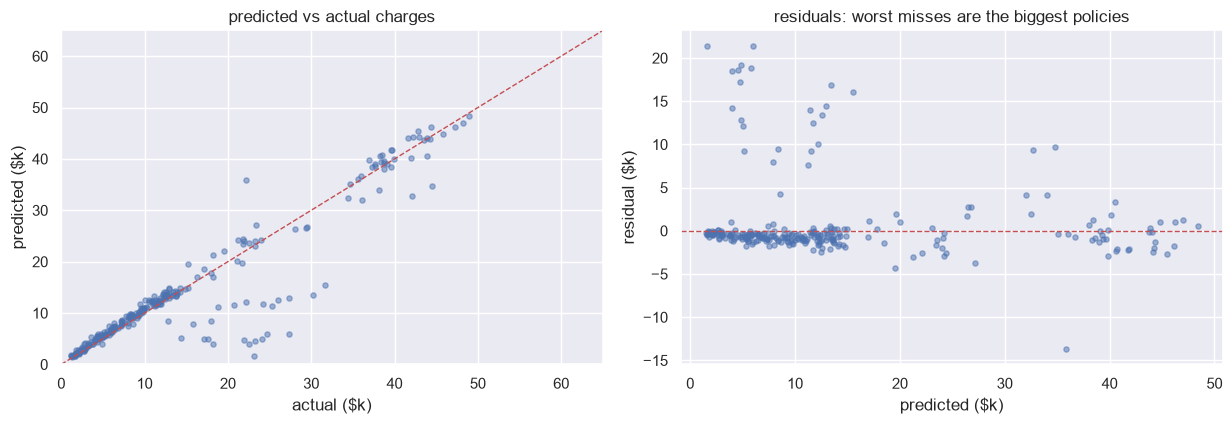

{'MAE_$': 2150.3, 'RMSE_$': 4589.6, 'R²': 0.9}


In [8]:
pred_usd = np.expm1(final_gbm.predict(X_test))
true_usd = np.expm1(y_test)
resid_usd = true_usd - pred_usd

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].scatter(true_usd / 1000, pred_usd / 1000, s=14, alpha=0.5)
lims = [0, 65]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("actual ($k)"); axes[0].set_ylabel("predicted ($k)")
axes[0].set_title("predicted vs actual charges")

axes[1].scatter(pred_usd / 1000, resid_usd / 1000, s=14, alpha=0.5)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("predicted ($k)"); axes[1].set_ylabel("residual ($k)")
axes[1].set_title("residuals: worst misses are the biggest policies")
plt.tight_layout(); plt.show()

print({k: round(v, 1) if isinstance(v, float) else v
       for k, v in dollar_metrics(y_test, final_gbm.predict(X_test)).items()})

### Summary takeaways

- Money targets are skewed: model `log1p`, report `expm1` - errors become relative.
- `staged_predict` + a validation split = data-driven choice of `n_estimators`;
  the U-shaped validation curve IS the overfitting knee made visible.
- Small ν (0.05) needs hundreds of trees; deeper trees shift the optimum earlier.
- `smoker` dominates importances here - when a single flag explains this much,
  sanity-check it in raw EDA before trusting the model's story.